In [34]:
import subprocess

subprocess.run(["pip", "install", "xgboost"], capture_output=True)

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0, stdout=b'Collecting xgboost\n  Downloading xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)\nRequirement already satisfied: numpy in /opt/anaconda3/lib/python3.11/site-packages (from xgboost) (1.26.4)\nRequirement already satisfied: scipy in /opt/anaconda3/lib/python3.11/site-packages (from xgboost) (1.11.4)\nDownloading xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)\n\x1b[?25l   \x1b\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\xe2\x94\x81\x1b \x1b0.0/2.3 MB\x1b \x1b?\x1b eta \x1b-:-

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('CustomerChurn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Churn'].value_counts())

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID    

In [36]:
df.drop(columns=["customerID"], inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df["TotalCharges"].dtype)
print(df["Churn"].value_counts())
print(df.isnull().sum().sum())

float64
Churn
0    5174
1    1869
Name: count, dtype: int64
0


/var/folders/c0/hkqjbl8n1b359xf20y52j6q00000gn/T/ipykernel_43858/63882676.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


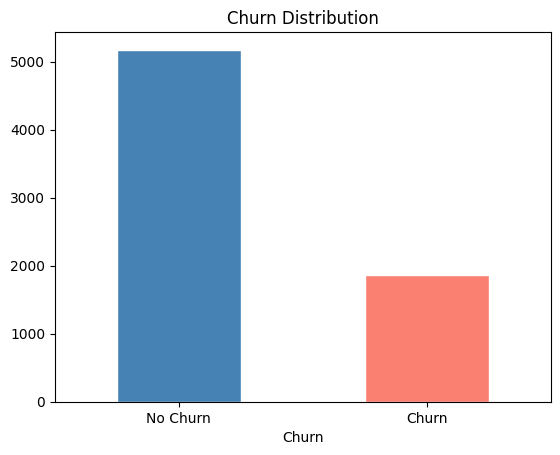

In [37]:
df["Churn"].value_counts().plot(
    kind="bar", color=["steelblue", "salmon"], edgecolor="white"
)
plt.title("Churn Distribution")
plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)
plt.show()

/var/folders/c0/hkqjbl8n1b359xf20y52j6q00000gn/T/ipykernel_43858/329913176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette=["steelblue", "salmon"])
/var/folders/c0/hkqjbl8n1b359xf20y52j6q00000gn/T/ipykernel_43858/329913176.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/c0/hkqjbl8n1b359xf20y52j6q00000gn/T/ipykernel_43858/329913176.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


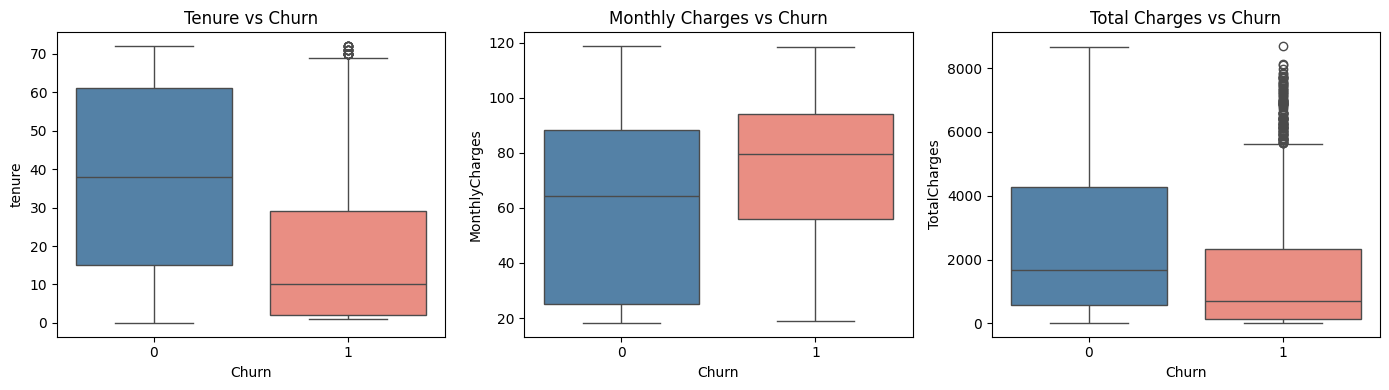

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette=["steelblue", "salmon"])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(
    data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette=["steelblue", "salmon"]
)
axes[1].set_title("Monthly Charges vs Churn")

sns.boxplot(
    data=df, x="Churn", y="TotalCharges", ax=axes[2], palette=["steelblue", "salmon"]
)
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()

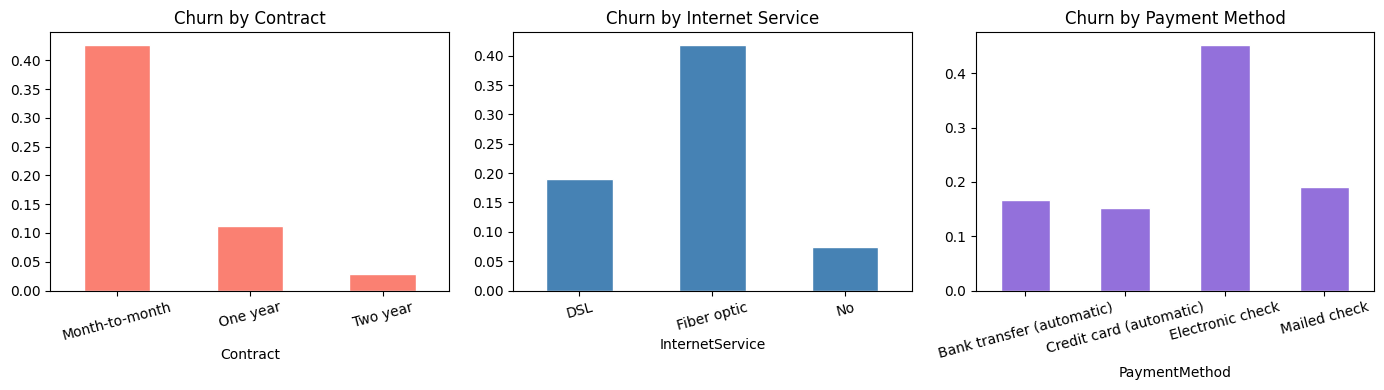

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby("Contract")["Churn"].mean().plot(
    kind="bar", ax=axes[0], color="salmon", edgecolor="white"
)
axes[0].set_title("Churn by Contract")
axes[0].tick_params(axis="x", rotation=15)

df.groupby("InternetService")["Churn"].mean().plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="white"
)
axes[1].set_title("Churn by Internet Service")
axes[1].tick_params(axis="x", rotation=15)

df.groupby("PaymentMethod")["Churn"].mean().plot(
    kind="bar", ax=axes[2], color="mediumpurple", edgecolor="white"
)
axes[2].set_title("Churn by Payment Method")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [41]:
# Charge per month of tenure
df["charge_per_tenure"] = df["MonthlyCharges"] / (df["tenure"] + 1)

# Has any streaming service
df["has_streaming"] = ((df["StreamingTV"] > 0) | (df["StreamingMovies"] > 0)).astype(
    int
)

# Has any security service
df["has_security"] = ((df["OnlineSecurity"] > 0) | (df["DeviceProtection"] > 0)).astype(
    int
)

print(df[["charge_per_tenure", "has_streaming", "has_security"]].head())

   charge_per_tenure  has_streaming  has_security
0          14.925000              0             0
1           1.627143              0             1
2          17.950000              0             1
3           0.919565              0             1
4          23.566667              0             0


In [42]:
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separate majority and minority
majority = df[df["Churn"] == 0]
minority = df[df["Churn"] == 1]

# Oversample minority class
minority_upsampled = resample(
    minority, replace=True, n_samples=len(majority), random_state=42
)

# Combine
df_balanced = pd.concat([majority, minority_upsampled])

print("Before balancing:", df["Churn"].value_counts().to_dict())
print("After balancing :", df_balanced["Churn"].value_counts().to_dict())

# New X and y
X = df_balanced.drop(columns=["Churn"])
y = df_balanced["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Before balancing: {0: 5174, 1: 1869}
After balancing : {0: 5174, 1: 5174}


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1044
           1       0.75      0.81      0.78      1026

    accuracy                           0.77      2070
   macro avg       0.77      0.77      0.77      2070
weighted avg       0.77      0.77      0.77      2070



In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      1044
           1       0.76      0.82      0.79      1026

    accuracy                           0.79      2070
   macro avg       0.79      0.79      0.79      2070
weighted avg       0.79      0.79      0.79      2070



In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      1044
           1       0.88      0.97      0.92      1026

    accuracy                           0.92      2070
   macro avg       0.93      0.92      0.92      2070
weighted avg       0.93      0.92      0.92      2070



In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1044
           1       0.83      0.95      0.88      1026

    accuracy                           0.88      2070
   macro avg       0.88      0.88      0.87      2070
weighted avg       0.88      0.88      0.87      2070



/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


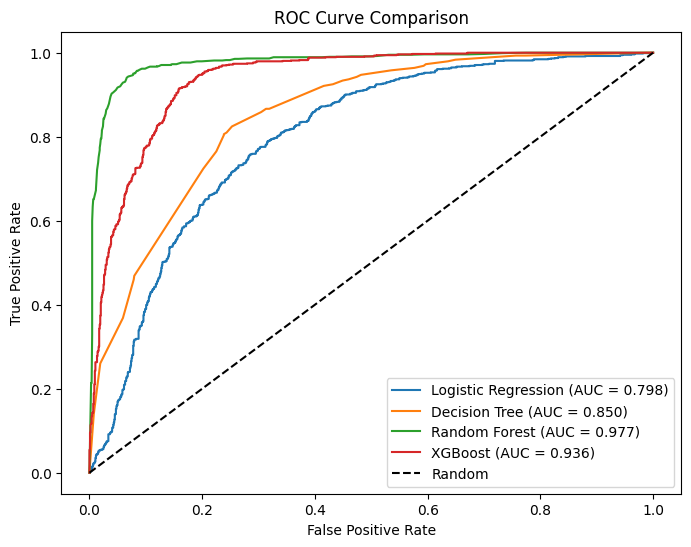

In [50]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
ax.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.3f})",
)

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, dt.predict_proba(X_test)[:, 1])
ax.plot(
    fpr,
    tpr,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1]):.3f})",
)

# Random Forest
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
ax.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.3f})",
)

# XGBoost
fpr, tpr, _ = roc_curve(y_test, xgb.predict_proba(X_test)[:, 1])
ax.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]):.3f})",
)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

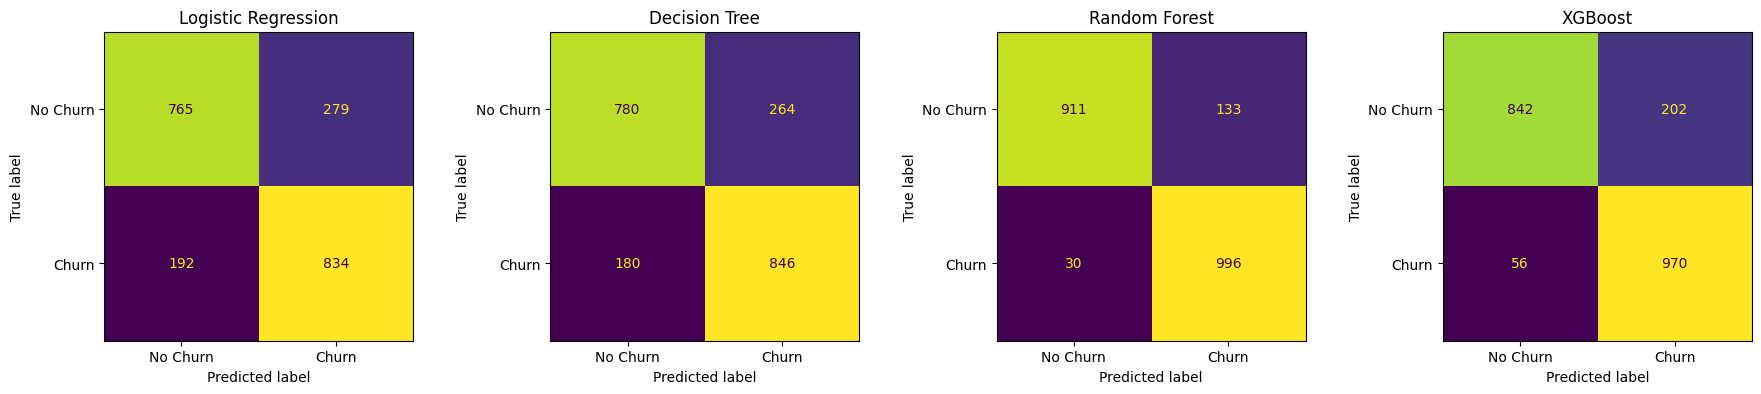

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title("Logistic Regression")

# Decision Tree
cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[1], colorbar=False
)
axes[1].set_title("Decision Tree")

# Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[2], colorbar=False
)
axes[2].set_title("Random Forest")

# XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
    ax=axes[3], colorbar=False
)
axes[3].set_title("XGBoost")

plt.tight_layout()
plt.show()

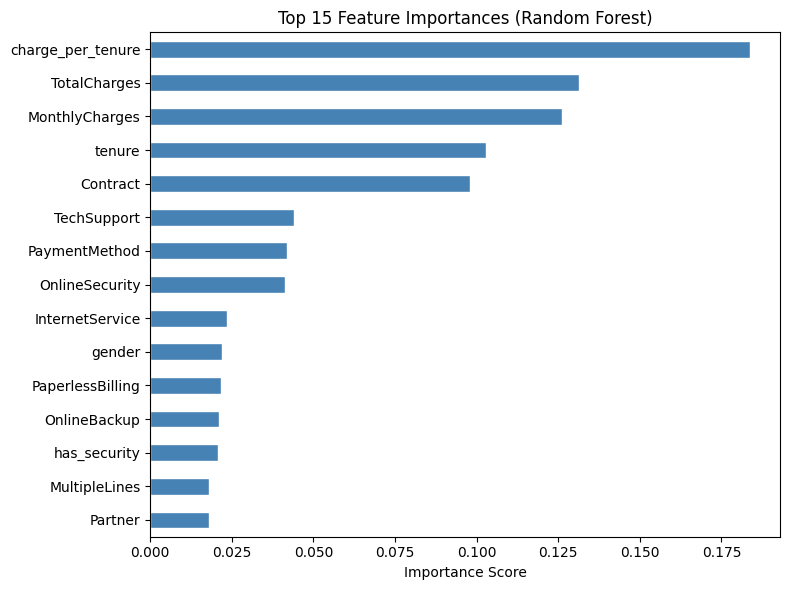

In [52]:
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)

feat_imp.plot(kind="barh", figsize=(8, 6), color="steelblue", edgecolor="white")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [55]:
import subprocess

subprocess.run(["pip", "install", "--upgrade", "shap", "scipy"], capture_output=True)

CompletedProcess(args=['pip', 'install', '--upgrade', 'shap', 'scipy'], returncode=0, stdout=b'Requirement already satisfied: shap in /opt/anaconda3/lib/python3.11/site-packages (0.51.0)\nRequirement already satisfied: scipy in /opt/anaconda3/lib/python3.11/site-packages (1.17.1)\nRequirement already satisfied: numpy>=2 in /opt/anaconda3/lib/python3.11/site-packages (from shap) (2.3.5)\nRequirement already satisfied: scikit-learn in /opt/anaconda3/lib/python3.11/site-packages (from shap) (1.2.2)\nRequirement already satisfied: pandas in /opt/anaconda3/lib/python3.11/site-packages (from shap) (2.2.2)\nRequirement already satisfied: tqdm>=4.27.0 in /opt/anaconda3/lib/python3.11/site-packages (from shap) (4.67.3)\nRequirement already satisfied: packaging>20.9 in /opt/anaconda3/lib/python3.11/site-packages (from shap) (23.1)\nRequirement already satisfied: slicer==0.0.8 in /opt/anaconda3/lib/python3.11/site-packages (from shap) (0.0.8)\nRequirement already satisfied: numba in /opt/anaconda

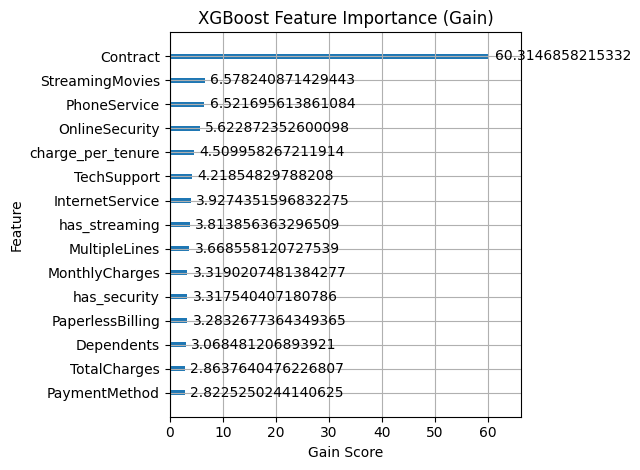

In [57]:
from xgboost import plot_importance

plot_importance(
    xgb,
    max_num_features=15,
    importance_type="gain",
    title="XGBoost Feature Importance (Gain)",
    xlabel="Gain Score",
    ylabel="Feature",
)
plt.tight_layout()
plt.show()